<a href="https://colab.research.google.com/github/adityanaik3702-hub/my-project/blob/main/data_Hand_V_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("/content/drive/MyDrive/Real_Estate_Messy_Dataset.csv", encoding='latin1', on_bad_lines='skip')
print(df.head())

df.head()

df.tail()



  Property_ID       City Property_Type Bedrooms Area_SqFt Price_Lakhs  \
0   PROP00001        NaN           NaN      NaN       NaN         NaN   
1   PROP00002       Pune          flat      4.0       NaN         NaN   
2   PROP00003        NaN           NaN      3.0       2.0         NaN   
3   PROP00004        NaN           NaN      4.0       NaN         NaN   
4   PROP00005  bangalore           NaN      NaN     372.8      9999.0   

  Age_Years Furnishing_Status Distance_to_Center_km      Listing_Status  
0       NaN               NaN                   4.6                 NaN  
1       1.9    semi furnished                   0.5              RESALE  
2       NaN    Semi-Furnished                   NaN  under construction  
3    9999.0         Furnished                  29.7                 NaN  
4      26.7         FURNISHED                   NaN       ready to move  


,Property_ID,City,Property_Type,Bedrooms,Area_SqFt,Price_Lakhs,Age_Years,Furnishing_Status,Distance_to_Center_km,Listing_Status
5351,PROP00428,Bangalore,NaN,5.0,NaN,NaN,NaN,Furnished,4.7,NaN
5352,PROP03641,NaN,NaN,4.0,NaN,NaN,16.1,Unfurnished,NaN,ready to move
5353,PROP01500,NaN,NaN,3.0,1673.7,118.97,1.2,semi furnished,NaN,resale
5354,PROP04764,MUMBAI,NaN,NaN,NaN,NaN,NaN,Furnished,18.1,ready to move
5355,PROP02088,NaN,APARTMENT,2.0,NaN,124.77,NaN,furnished,NaN,NaN


In [3]:
df.info()

df.describe()

df.shape
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5356 entries, 0 to 5355
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Property_ID            5277 non-null   object
 1   City                   2794 non-null   object
 2   Property_Type          2537 non-null   object
 3   Bedrooms               2819 non-null   object
 4   Area_SqFt              2957 non-null   object
 5   Price_Lakhs            2786 non-null   object
 6   Age_Years              2862 non-null   object
 7   Furnishing_Status      2515 non-null   object
 8   Distance_to_Center_km  2691 non-null   object
 9   Listing_Status         2486 non-null   object
dtypes: object(10)
memory usage: 418.6+ KB


Index(['Property_ID', 'City', 'Property_Type', 'Bedrooms', 'Area_SqFt',
       'Price_Lakhs', 'Age_Years', 'Furnishing_Status',
       'Distance_to_Center_km', 'Listing_Status'],
      dtype='object')

In [4]:
df.isnull().sum()


,0
Property_ID,79
City,2562
Property_Type,2819
Bedrooms,2537
Area_SqFt,2399
Price_Lakhs,2570
Age_Years,2494
Furnishing_Status,2841
Distance_to_Center_km,2665
Listing_Status,2870


In [5]:
numeric_cols = [
    "Bedrooms",
    "Area_SqFt",
    "Price_Lakhs",
    "Age_Years",
    "Distance_to_Center_km"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [6]:
df["Bedrooms"].fillna(df["Bedrooms"].median(), inplace=True)
df["Area_SqFt"].fillna(df["Area_SqFt"].median(), inplace=True)
df["Price_Lakhs"].fillna(df["Price_Lakhs"].median(), inplace=True)
df["Age_Years"].fillna(df["Age_Years"].median(), inplace=True)
df["Distance_to_Center_km"].fillna(df["Distance_to_Center_km"].median(), inplace=True)




/tmp/ipykernel_7565/2764501233.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Bedrooms"].fillna(df["Bedrooms"].median(), inplace=True)
/tmp/ipykernel_7565/2764501233.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=

In [7]:
df["Property_ID"] = df["Property_ID"].fillna(df["Property_ID"].mode()[0])
df["City"] = df["City"].fillna(df["City"].mode()[0])
df["Property_Type"] = df["Property_Type"].fillna(df["Property_Type"].mode()[0])
df["Furnishing_Status"] = df["Furnishing_Status"].fillna(df["Furnishing_Status"].mode()[0])
df["Listing_Status"] = df["Listing_Status"].fillna(df["Listing_Status"].mode()[0])

In [8]:
df.isnull().sum()

,0
Property_ID,0
City,0
Property_Type,0
Bedrooms,0
Area_SqFt,0
Price_Lakhs,0
Age_Years,0
Furnishing_Status,0
Distance_to_Center_km,0
Listing_Status,0


In [9]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 129


In [10]:
df = df.drop_duplicates()

In [11]:

df["Bedrooms"] = df["Bedrooms"].round()
df.head()


,Property_ID,City,Property_Type,Bedrooms,Area_SqFt,Price_Lakhs,Age_Years,Furnishing_Status,Distance_to_Center_km,Listing_Status
0,PROP00001,Delhi,Independent House,3.0,1208.3,86.575,6.4,semi furnished,4.6,Resale
1,PROP00002,Pune,flat,4.0,1208.3,86.575,1.9,semi furnished,0.5,RESALE
2,PROP00003,Delhi,Independent House,3.0,2.0,86.575,6.4,Semi-Furnished,9.4,under construction
3,PROP00004,Delhi,Independent House,4.0,1208.3,86.575,9999.0,Furnished,29.7,Resale
4,PROP00005,bangalore,Independent House,3.0,372.8,9999.000,26.7,FURNISHED,9.4,ready to move


In [13]:
df = df[df["Bedrooms"] < 7]
df = df[df["Area_SqFt"] < 10000]

df.dtypes

,0
Property_ID,object
City,object
Property_Type,object
Bedrooms,float64
Area_SqFt,float64
Price_Lakhs,float64
Age_Years,float64
Furnishing_Status,object
Distance_to_Center_km,float64
Listing_Status,object


In [14]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 4751 entries, 0 to 5354
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Property_ID            4751 non-null   object 
 1   City                   4751 non-null   object 
 2   Property_Type          4751 non-null   object 
 3   Bedrooms               4751 non-null   float64
 4   Area_SqFt              4751 non-null   float64
 5   Price_Lakhs            4751 non-null   float64
 6   Age_Years              4751 non-null   float64
 7   Furnishing_Status      4751 non-null   object 
 8   Distance_to_Center_km  4751 non-null   float64
 9   Listing_Status         4751 non-null   object 
dtypes: float64(5), object(5)
memory usage: 408.3+ KB


In [ ]:
df.to_csv("cleaned_property_data.csv", index=False)


In [ ]:
import os

print(os.listdir())

['.config', 'cleaned_property_data.csv', 'cleaned_data.csv', 'drive', 'sample_data']


In [15]:
print(df['Area_SqFt'].dtype)
print(df['Area_SqFt'].describe())
print(df['Area_SqFt'].unique()[:20])

float64
count    4751.000000
mean     1182.657777
std       326.322841
min         0.500000
25%      1165.750000
50%      1208.300000
75%      1216.900000
max      2521.500000
Name: Area_SqFt, dtype: float64
[1.2083e+03 2.0000e+00 3.7280e+02 1.6798e+03 4.9200e+02 1.8292e+03
 1.5245e+03 8.8780e+02 8.9270e+02 1.2238e+03 1.2758e+03 8.6320e+02
 1.2885e+03 1.4869e+03 7.8190e+02 1.5152e+03 1.7546e+03 1.3213e+03
 1.0000e+00 1.7787e+03]


In [16]:

print("Too small (< 100 sqft):", (df['Area_SqFt'] < 100).sum())
print("Too large (> 10000 sqft):", (df['Area_SqFt'] > 10000).sum())
df = df[(df['Area_SqFt'] >= 100) & (df['Area_SqFt'] <= 10000)]

df["Area_SqFt"] = df["Area_SqFt"].round()
print(df['Area_SqFt'].describe())


Too small (< 100 sqft): 96
Too large (> 10000 sqft): 0
count    4655.00000
mean     1206.87884
std       281.59529
min       300.00000
25%      1190.50000
50%      1208.00000
75%      1225.00000
max      2522.00000
Name: Area_SqFt, dtype: float64


In [17]:
print(df['Age_Years'].dtype)
print(df['Age_Years'].describe())
print(df['Age_Years'].unique()[:20])

float64
count    4655.000000
mean      106.482986
std       884.377800
min         0.000000
25%         6.000000
50%         6.400000
75%         6.700000
max      9999.000000
Name: Age_Years, dtype: float64
[6.400e+00 1.900e+00 9.999e+03 2.670e+01 4.300e+00 2.150e+01 1.610e+01
 4.900e+00 7.600e+00 5.900e+00 7.000e-01 7.200e+00 2.800e+00 1.800e+00
 9.990e+02 4.700e+00 4.100e+00 1.000e+00 1.370e+01 9.100e+00]


In [20]:
# Check how many rows are affected
print("Too large (> 100 years):", (df['Age_Years'] > 100).sum())
print("Zero age:", (df['Age_Years'] == 0).sum())

# Realistic range: 0 (new) to 100 years old
df = df[(df['Age_Years'] >= 0) & (df['Age_Years'] <= 100)]

df["Age_Years"] = df["Age_Years"].round()
print(df['Age_Years'].describe())
df.head()

Too large (> 100 years): 0
Zero age: 135
count    4327.000000
mean        6.977583
std         5.312405
min         0.000000
25%         6.000000
50%         6.000000
75%         6.000000
max        40.000000
Name: Age_Years, dtype: float64


,Property_ID,City,Property_Type,Bedrooms,Area_SqFt,Price_Lakhs,Age_Years,Furnishing_Status,Distance_to_Center_km,Listing_Status
0,PROP00001,Delhi,Independent House,3.0,1208.0,87.0,6.0,semi furnished,4.6,Resale
1,PROP00002,Pune,flat,4.0,1208.0,87.0,2.0,semi furnished,0.5,RESALE
5,PROP00006,Delhi,Independent House,3.0,1680.0,87.0,6.0,semi furnished,9.4,Resale
6,PROP00007,MUMBAI,independent house,2.0,492.0,87.0,4.0,semi furnished,14.8,resale
7,PROP00008,Delhi,Independent House,4.0,1829.0,110.0,22.0,unfurnished,9.3,Resale


In [19]:
print(df['Price_Lakhs'].dtype)
print(df['Price_Lakhs'].describe())
print(df['Price_Lakhs'].unique()[:20])



# Check how many rows are affected
print("Too small (< 10 lakhs):", (df['Price_Lakhs'] < 10).sum())
print("Too large (> 500 lakhs):", (df['Price_Lakhs'] > 500).sum())

# Realistic range for Indian real estate: 10 lakhs to 500 lakhs (5 crore)
df = df[(df['Price_Lakhs'] >= 10) & (df['Price_Lakhs'] <= 500)]

# Verify
df["Price_Lakhs"] = df["Price_Lakhs"].round()
print(df['Price_Lakhs'].describe())

float64
count    4495.000000
mean      165.506010
std       763.345504
min         0.500000
25%        85.770000
50%        86.575000
75%        86.575000
max      9999.000000
Name: Price_Lakhs, dtype: float64
[  86.575 9999.     109.77    79.99   105.56   111.48   102.73    92.85
   83.65    67.79    86.58    96.75    33.87   110.84    69.14   101.58
   55.76    76.54    96.36   106.97 ]
Too small (< 10 lakhs): 93
Too large (> 500 lakhs): 75
count    4327.000000
mean       86.597874
std        20.988562
min        10.000000
25%        87.000000
50%        87.000000
75%        87.000000
max       186.000000
Name: Price_Lakhs, dtype: float64


In [21]:
print(df['Furnishing_Status'].dtype)
print(df['Furnishing_Status'].describe())
print(df['Furnishing_Status'].unique()[:20])



# Standardize: lowercase + strip spaces + remove hyphens
df['Furnishing_Status'] = df['Furnishing_Status'].str.lower().str.strip()
df['Furnishing_Status'] = df['Furnishing_Status'].str.replace('-', ' ')

# Verify
print(df['Furnishing_Status'].value_counts())


print(df['Listing_Status'].dtype)
print(df['Listing_Status'].describe())
print(df['Listing_Status'].unique()[:20])

df['Listing_Status'] = df['Listing_Status'].str.upper().str.strip()
df['Listing_Status'] = df['Listing_Status'].str.replace('-', ' ')


df.reset_index(drop=True, inplace=True)


object
count               4327
unique                 8
top       semi furnished
freq                2579
Name: Furnishing_Status, dtype: object
['semi furnished' 'unfurnished' 'FURNISHED' 'Semi-Furnished' 'Furnished'
 'Semi Furnished' 'furnished' 'Unfurnished']
Furnishing_Status
semi furnished    3076
furnished          779
unfurnished        472
Name: count, dtype: int64
object
count       4327
unique         8
top       Resale
freq        2570
Name: Listing_Status, dtype: object
['Resale' 'RESALE' 'resale' 'ready to move' 'READY TO MOVE'
 'Under Construction' 'under construction' 'Ready to Move']


In [23]:


# 1. Fix City - strip spaces and title case
df['City'] = df['City'].str.strip().str.title()

# 2. Fix Property_Type - strip spaces and title case
df['Property_Type'] = df['Property_Type'].str.strip().str.title()

# 3. Remove duplicate Property_IDs (keep first)
df = df.drop_duplicates(subset='Property_ID', keep='first')

# Check results
print("Shape after cleaning:", df.shape)
print("\nCity unique values:\n", df['City'].unique())
print("\nProperty_Type unique values:\n", df['Property_Type'].unique())
print("\nDuplicate Property_IDs:", df['Property_ID'].duplicated().sum())

# Save
df.to_csv('cleaned_v2.csv', index=False)
print("\nSaved as cleaned_v2.csv")



# Check how many such rows
print(df[df['Distance_to_Center_km'] > 500].shape[0])

# Remove outliers (anything above 100km is unrealistic for city properties)
df = df[df['Distance_to_Center_km'] <= 100]

df.to_csv('cleaned_v2.csv', index=False)
print("Done! Shape:", df.shape)


Shape after cleaning: (4206, 10)

City unique values:
 ['Delhi' 'Pune' 'Mumbai' 'Kolkata' 'Bangalore' 'Chennai' 'Hyderabad']

Property_Type unique values:
 ['Independent House' 'Flat' 'Apartment' 'Studio' 'Penthouse' 'Villa']

Duplicate Property_IDs: 0

Saved as cleaned_v2.csv
143
Done! Shape: (4063, 10)


In [ ]:
%whos DataFrame
df.to_csv('cleaned.csv', index=False)

from google.colab import files
files.download('cleaned.csv')

Variable   Type         Data/Info
---------------------------------
df         DataFrame         Property_ID     City<...>n[4063 rows x 10 columns]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

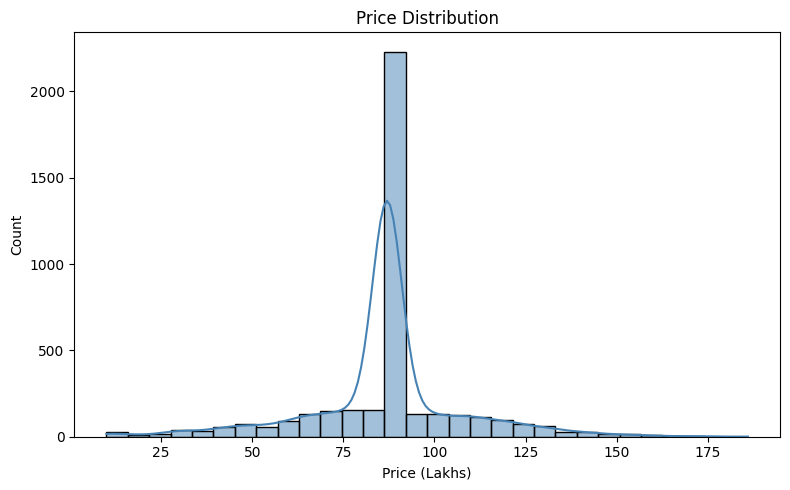

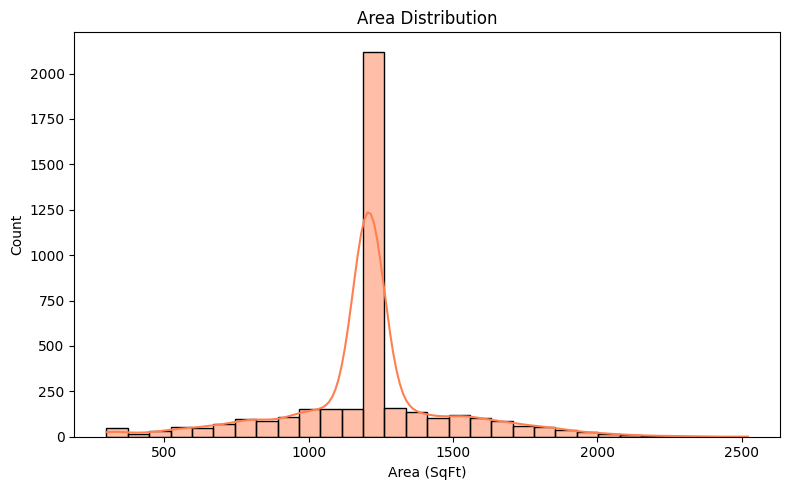

/tmp/ipykernel_7565/553517931.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='City', y='Price_Lakhs', palette='Set2')


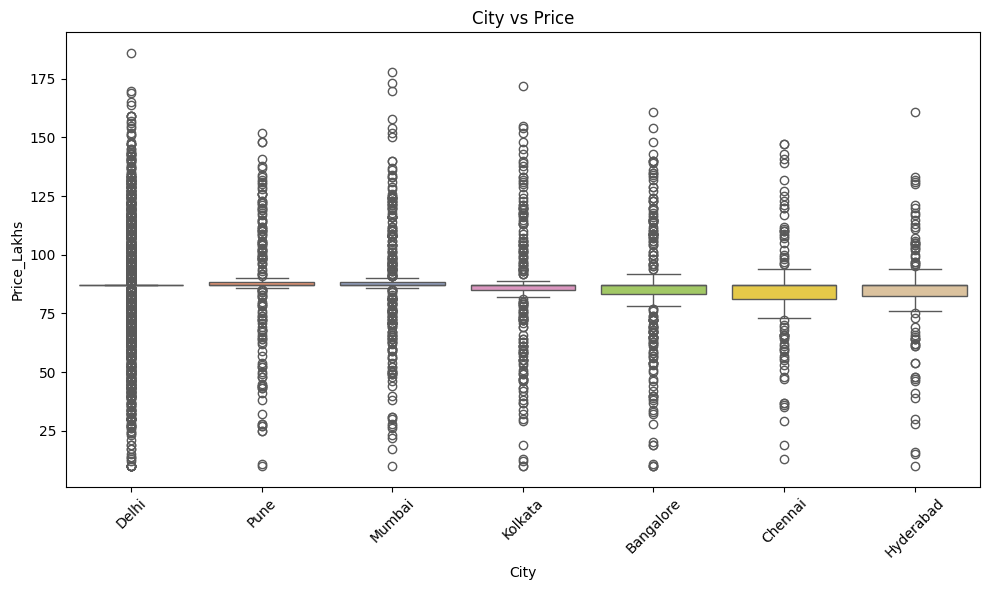

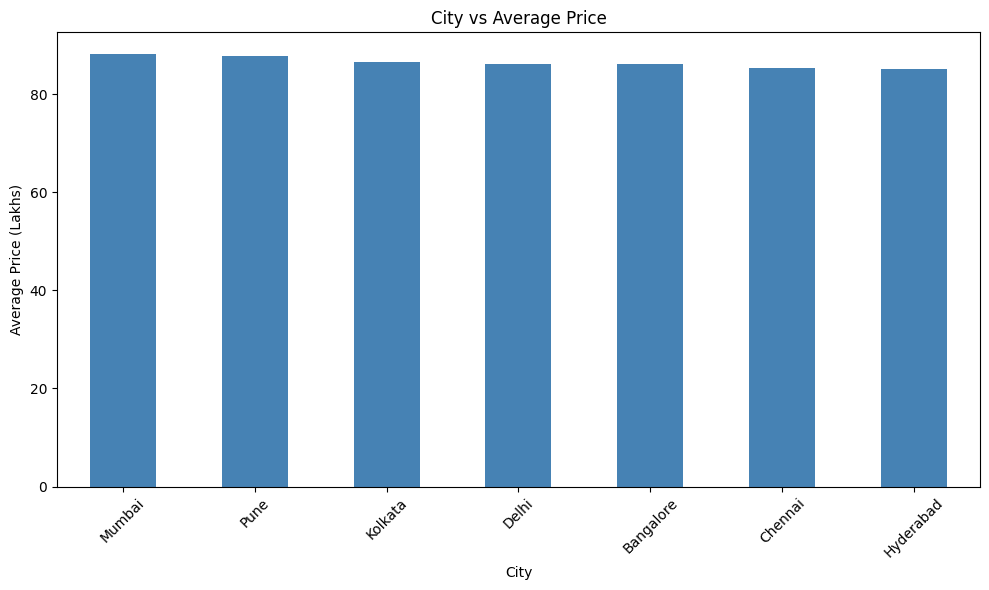

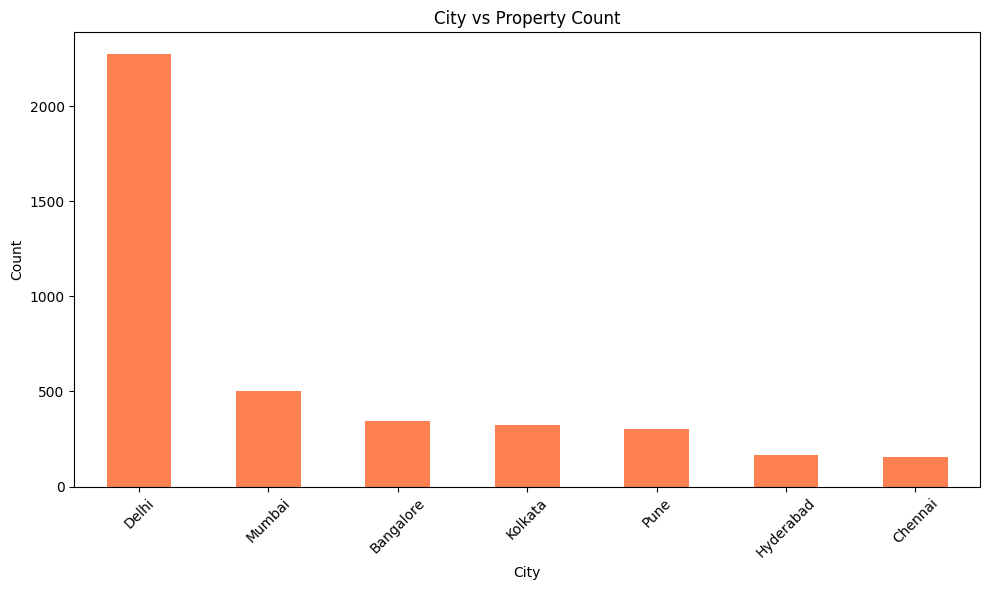

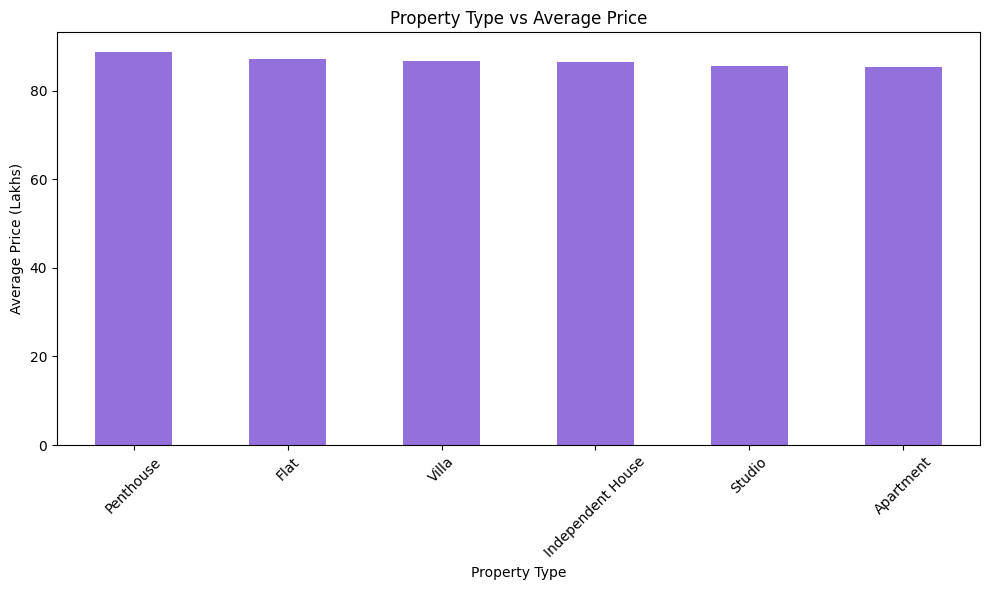

/tmp/ipykernel_7565/553517931.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Furnishing_Status', y='Price_Lakhs', palette='pastel')


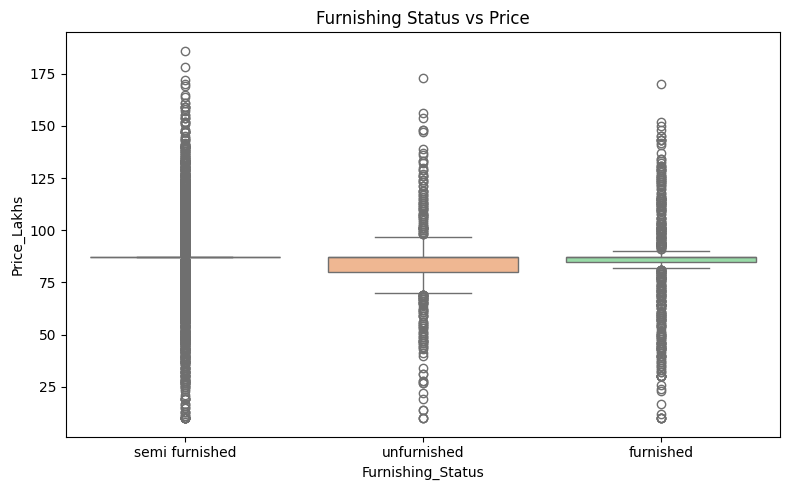

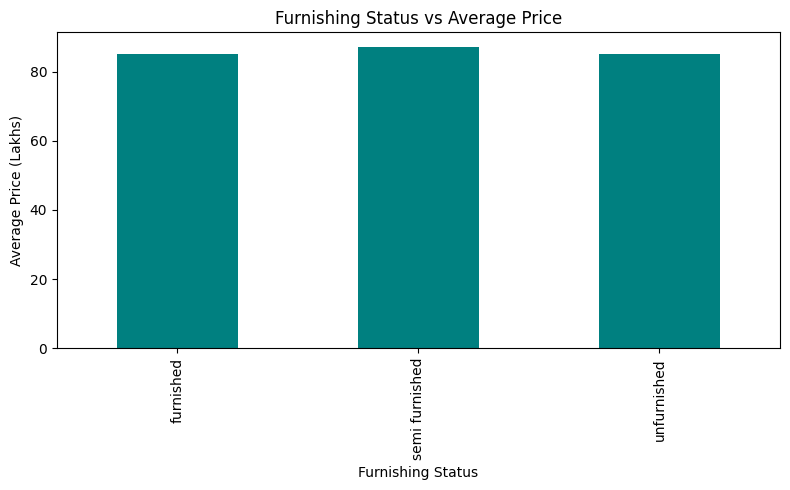

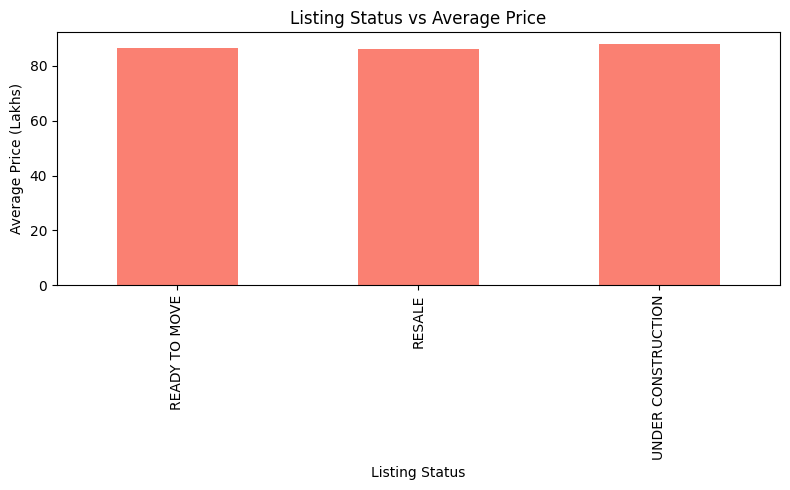

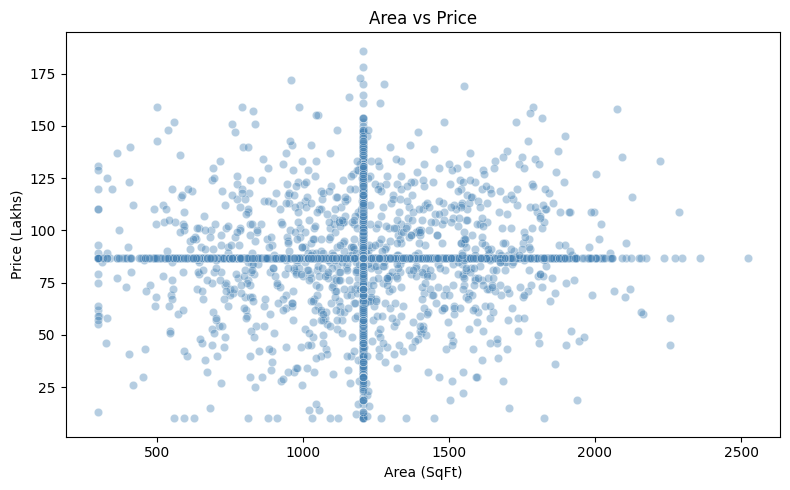

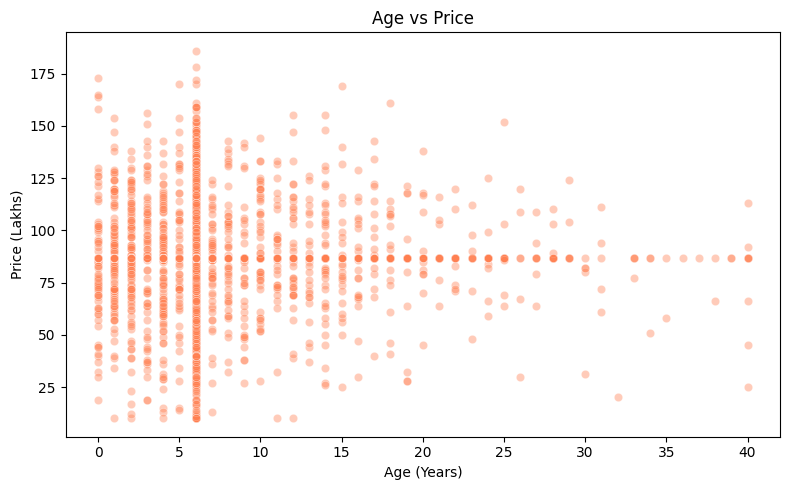

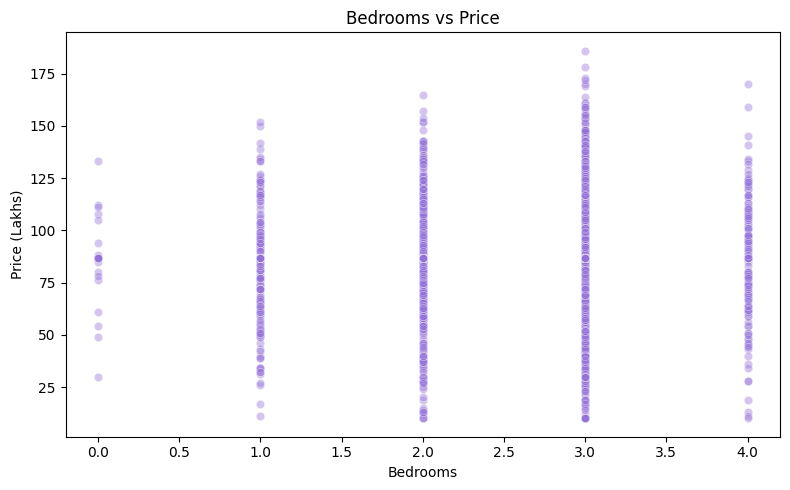

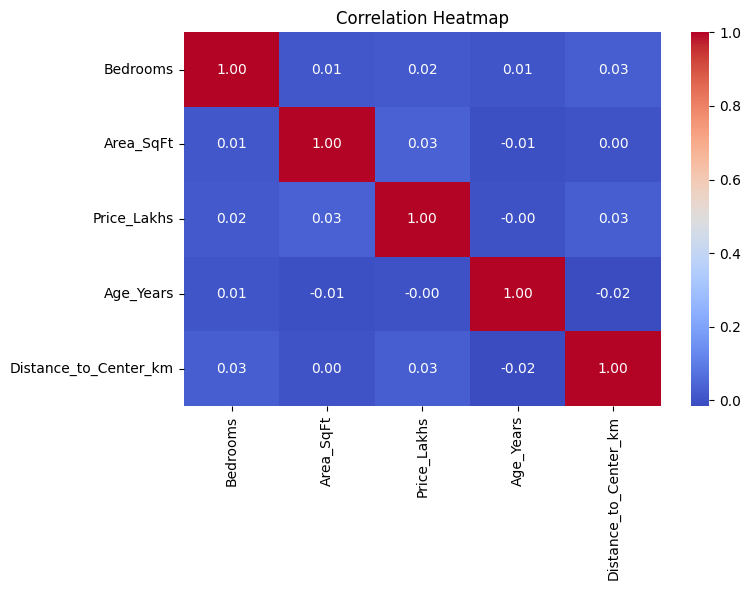

In [25]:

import seaborn as sns

# ─────────────────────────────────────────
# 1. Price Distribution (Histogram)
# ─────────────────────────────────────────
plt.figure(figsize=(8,5))
sns.histplot(df['Price_Lakhs'], bins=30, kde=True, color='steelblue')
plt.title('Price Distribution')
plt.xlabel('Price (Lakhs)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────
# 2. Area Distribution (Histogram)
# ─────────────────────────────────────────
plt.figure(figsize=(8,5))
sns.histplot(df['Area_SqFt'], bins=30, kde=True, color='coral')
plt.title('Area Distribution')
plt.xlabel('Area (SqFt)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────
# 3. City vs Price (Boxplot)
# ─────────────────────────────────────────
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='City', y='Price_Lakhs', palette='Set2')
plt.title('City vs Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────
# 4. City vs Average Price (Bar Chart)
# ─────────────────────────────────────────
plt.figure(figsize=(10,6))
df.groupby('City')['Price_Lakhs'].mean().sort_values(ascending=False).plot(kind='bar', color='steelblue')
plt.title('City vs Average Price')
plt.xlabel('City')
plt.ylabel('Average Price (Lakhs)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────
# 5. City vs Property Count (Bar Chart)
# ─────────────────────────────────────────
plt.figure(figsize=(10,6))
df['City'].value_counts().plot(kind='bar', color='coral')
plt.title('City vs Property Count')
plt.xlabel('City')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────
# 6. Property Type vs Average Price (Bar Chart)
# ─────────────────────────────────────────
plt.figure(figsize=(10,6))
df.groupby('Property_Type')['Price_Lakhs'].mean().sort_values(ascending=False).plot(kind='bar', color='mediumpurple')
plt.title('Property Type vs Average Price')
plt.xlabel('Property Type')
plt.ylabel('Average Price (Lakhs)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────
# 7. Furnishing Status vs Price (Boxplot)
# ─────────────────────────────────────────
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Furnishing_Status', y='Price_Lakhs', palette='pastel')
plt.title('Furnishing Status vs Price')
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────
# 8. Furnishing Status vs Average Price (Bar Chart)
# ─────────────────────────────────────────
plt.figure(figsize=(8,5))
df.groupby('Furnishing_Status')['Price_Lakhs'].mean().plot(kind='bar', color='teal')
plt.title('Furnishing Status vs Average Price')
plt.xlabel('Furnishing Status')
plt.ylabel('Average Price (Lakhs)')
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────
# 9. Listing Status vs Average Price (Bar Chart)
# ─────────────────────────────────────────
plt.figure(figsize=(8,5))
df.groupby('Listing_Status')['Price_Lakhs'].mean().plot(kind='bar', color='salmon')
plt.title('Listing Status vs Average Price')
plt.xlabel('Listing Status')
plt.ylabel('Average Price (Lakhs)')
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────
# 10. Area vs Price (Scatter)
# ─────────────────────────────────────────
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Area_SqFt', y='Price_Lakhs', alpha=0.4, color='steelblue')
plt.title('Area vs Price')
plt.xlabel('Area (SqFt)')
plt.ylabel('Price (Lakhs)')
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────
# 11. Age vs Price (Scatter)
# ─────────────────────────────────────────
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Age_Years', y='Price_Lakhs', alpha=0.4, color='coral')
plt.title('Age vs Price')
plt.xlabel('Age (Years)')
plt.ylabel('Price (Lakhs)')
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────
# 12. Bedrooms vs Price (Scatter)
# ─────────────────────────────────────────
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Bedrooms', y='Price_Lakhs', alpha=0.4, color='mediumpurple')
plt.title('Bedrooms vs Price')
plt.xlabel('Bedrooms')
plt.ylabel('Price (Lakhs)')
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────
# 13. Correlation Heatmap
# ─────────────────────────────────────────
plt.figure(figsize=(8,6))
numeric_cols = ['Bedrooms', 'Area_SqFt', 'Price_Lakhs', 'Age_Years', 'Distance_to_Center_km']
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()